Preparation des données


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix

# Charger le dataset depuis le fichier CSV
data = pd.read_csv("data_.csv")

# Vérifier les premières lignes pour comprendre la structure
print(data.head())

# Vérifier si une colonne cible est présente, sinon l'ajouter manuellement si nécessaire
if 'target' not in data.columns:
    print("Aucune colonne 'target' détectée. Veuillez vérifier votre fichier CSV.")


         Date Location  MinTemp  MaxTemp  Rainfall  Evaporation  Sunshine  \
0  2008-12-01   Albury     13.4     22.9       0.6          NaN       NaN   
1  2008-12-02   Albury      7.4     25.1       0.0          NaN       NaN   
2  2008-12-03   Albury     12.9     25.7       0.0          NaN       NaN   
3  2008-12-04   Albury      9.2     28.0       0.0          NaN       NaN   
4  2008-12-05   Albury     17.5     32.3       1.0          NaN       NaN   

  WindGustDir  WindGustSpeed WindDir9am  ... Humidity9am  Humidity3pm  \
0           W           44.0          W  ...        71.0         22.0   
1         WNW           44.0        NNW  ...        44.0         25.0   
2         WSW           46.0          W  ...        38.0         30.0   
3          NE           24.0         SE  ...        45.0         16.0   
4           W           41.0        ENE  ...        82.0         33.0   

   Pressure9am  Pressure3pm  Cloud9am  Cloud3pm  Temp9am  Temp3pm  RainToday  \
0       1007.7    

1. Nettoyage des données :

Supprimer les colonnes inutiles si elles ne sont pas pertinentes (ex: Date, Location).
Gérer les valeurs manquantes (NaN) :
Supprimer les colonnes ayant trop de NaN (par exemple, Evaporation, Sunshine).
Remplir les NaN des colonnes numériques avec la médiane ou la moyenne.
Pour les colonnes catégorielles (WindGustDir, WindDir9am…), remplir avec la valeur la plus fréquente.

2. Encodage des variables catégorielles:

Convertir les colonnes comme RainToday et RainTomorrow en 0 et 1 (No → 0, Yes → 1).
Appliquer un One-Hot Encoding sur WindGustDir, WindDir9am, WindDir3pm pour convertir ces valeurs en nombres.

3. Normalisation des variables numériques :

Appliquer une normalisation min-max ou une standardisation (z-score) aux colonnes numériques pour équilibrer les échelles.

In [3]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder

# Charger le dataset
data = pd.read_csv("data_.csv")

# Afficher les infos de base
print("Avant nettoyage :")
print(data.info())

# 1. Supprimer les colonnes non pertinentes
columns_to_drop = ["Date", "Location"]  # On peut ajouter d'autres colonnes inutiles
data.drop(columns=columns_to_drop, inplace=True)

# 2. Gérer les valeurs manquantes
# Séparer les colonnes numériques et catégoriques
num_cols = data.select_dtypes(include=["float64", "int64"]).columns
cat_cols = data.select_dtypes(include=["object"]).columns

# Remplacer les NaN dans les colonnes numériques par la médiane
imputer_num = SimpleImputer(strategy="median")
data[num_cols] = imputer_num.fit_transform(data[num_cols])

# Remplacer les NaN dans les colonnes catégorielles par la valeur la plus fréquente
imputer_cat = SimpleImputer(strategy="most_frequent")
data[cat_cols] = imputer_cat.fit_transform(data[cat_cols])

# 3. Encodage des variables catégoriques
# Transformer "RainToday" et "RainTomorrow" en 0 et 1
data["RainToday"] = data["RainToday"].map({"No": 0, "Yes": 1})
data["RainTomorrow"] = data["RainTomorrow"].map({"No": 0, "Yes": 1})

# One-Hot Encoding pour les directions du vent
wind_columns = ["WindGustDir", "WindDir9am", "WindDir3pm"]
data = pd.get_dummies(data, columns=wind_columns)

# 4. Normalisation des données numériques
scaler = StandardScaler()  # Z-score normalisation
data[num_cols] = scaler.fit_transform(data[num_cols])

# Afficher les infos après nettoyage
print("Après nettoyage :")
print(data.info())

# Sauvegarder les données nettoyées
data.to_csv("data_cleaned.csv", index=False)

print("Données nettoyées et normalisées enregistrées sous 'data_cleaned.csv'")



Avant nettoyage :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am   

In [4]:
# Afficher les infos après nettoyage
print("Après nettoyage :")
print(data.info())

Après nettoyage :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 66 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   MinTemp          145460 non-null  float64
 1   MaxTemp          145460 non-null  float64
 2   Rainfall         145460 non-null  float64
 3   Evaporation      145460 non-null  float64
 4   Sunshine         145460 non-null  float64
 5   WindGustSpeed    145460 non-null  float64
 6   WindSpeed9am     145460 non-null  float64
 7   WindSpeed3pm     145460 non-null  float64
 8   Humidity9am      145460 non-null  float64
 9   Humidity3pm      145460 non-null  float64
 10  Pressure9am      145460 non-null  float64
 11  Pressure3pm      145460 non-null  float64
 12  Cloud9am         145460 non-null  float64
 13  Cloud3pm         145460 non-null  float64
 14  Temp9am          145460 non-null  float64
 15  Temp3pm          145460 non-null  float64
 16  RainToday        145

1. Sortie avant nettoyage (Avant nettoyage)
Résumé des données :

Nombre total d’échantillons : 145460 lignes

Nombre total de colonnes : 23

Valeurs manquantes : Présentes dans plusieurs colonnes, notamment :

Evaporation : Seulement 82,670 valeurs non-nulles sur 145,460 → 42% de valeurs manquantes !

Sunshine : Encore pire, 75,625 non-nulles → 48% de valeurs manquantes !

Cloud9am et Cloud3pm ont aussi une quantité significative de NaN.

WindGustDir, WindDir9am, WindDir3pm ont des valeurs manquantes dans environ 7-8% des lignes.


Problèmes détectés :
Colonnes inutiles :

Date (probablement inutile pour la modélisation)
Location (peut être utile mais difficile à encoder directement) Beaucoup de valeurs manquantes :

Evaporation et Sunshine ont trop de NaN, elles sont candidates pour suppression.

WindGustDir, WindDir9am, WindDir3pm doivent être imputées.


Colonnes catégoriques nécessitant un encodage :

RainToday, RainTomorrow → Convertir en 0 et 1.
WindGustDir, WindDir9am, WindDir3pm → One-Hot Encoding.

Colonnes numériques nécessitant une normalisation :

MinTemp, MaxTemp, Rainfall, WindSpeed9am, Humidity9am, Pressure9am, etc.

Différentes échelles → besoin de standardisation (Z-score ou Min-Max scaling).

2. Sortie après nettoyage (Après nettoyage)
Changements majeurs observés :

Colonnes réduites à des valeurs numériques exploitables :

Suppression de Date et Location.

Ajout de nombreuses colonnes binaires (du One-Hot Encoding pour les directions du vent).

RainToday et RainTomorrow sont maintenant des entiers (0 et 1).

Suppression des valeurs manquantes :

Colonnes numériques : Les NaN ont été remplacés par la médiane de chaque colonne.

Colonnes catégorielles (WindGustDir, WindDir9am, WindDir3pm) : Les NaN ont été remplacés par la valeur la plus fréquente.

Encodage des variables catégoriques (WindGustDir, WindDir9am, WindDir3pm) :

Avant : Une seule colonne avec des valeurs textuelles (W, N, S, etc.).

Après : Plusieurs colonnes binaires, une pour chaque direction (WindGustDir_E, WindDir9am_NW, etc.), où 1 signifie que la direction était présente.

Normalisation des colonnes numériques :

Application d'une standardisation (Z-score) pour homogénéiser les échelles.

Toutes les variables numériques ont maintenant une moyenne proche de 0 et un écart-type proche de 1.

Augmentation du nombre total de colonnes :

Avant : 23 colonnes
Après : 66 colonnes (principalement à cause de l'encodage One-Hot pour WindGustDir, WindDir9am, WindDir3pm).


Comparaison avant/après nettoyage
![alt text](image.png)

Boxplots (pour détecter les outliers)

Pourquoi utiliser un boxplot ?

✅ Détecter les valeurs aberrantes (outliers) → Les points qui s’éloignent fortement des autres.

✅ Visualiser la distribution des données → Position de la médiane, symétrie des données.

✅ Comparer plusieurs variables simultanément → Comprendre leur dispersion.

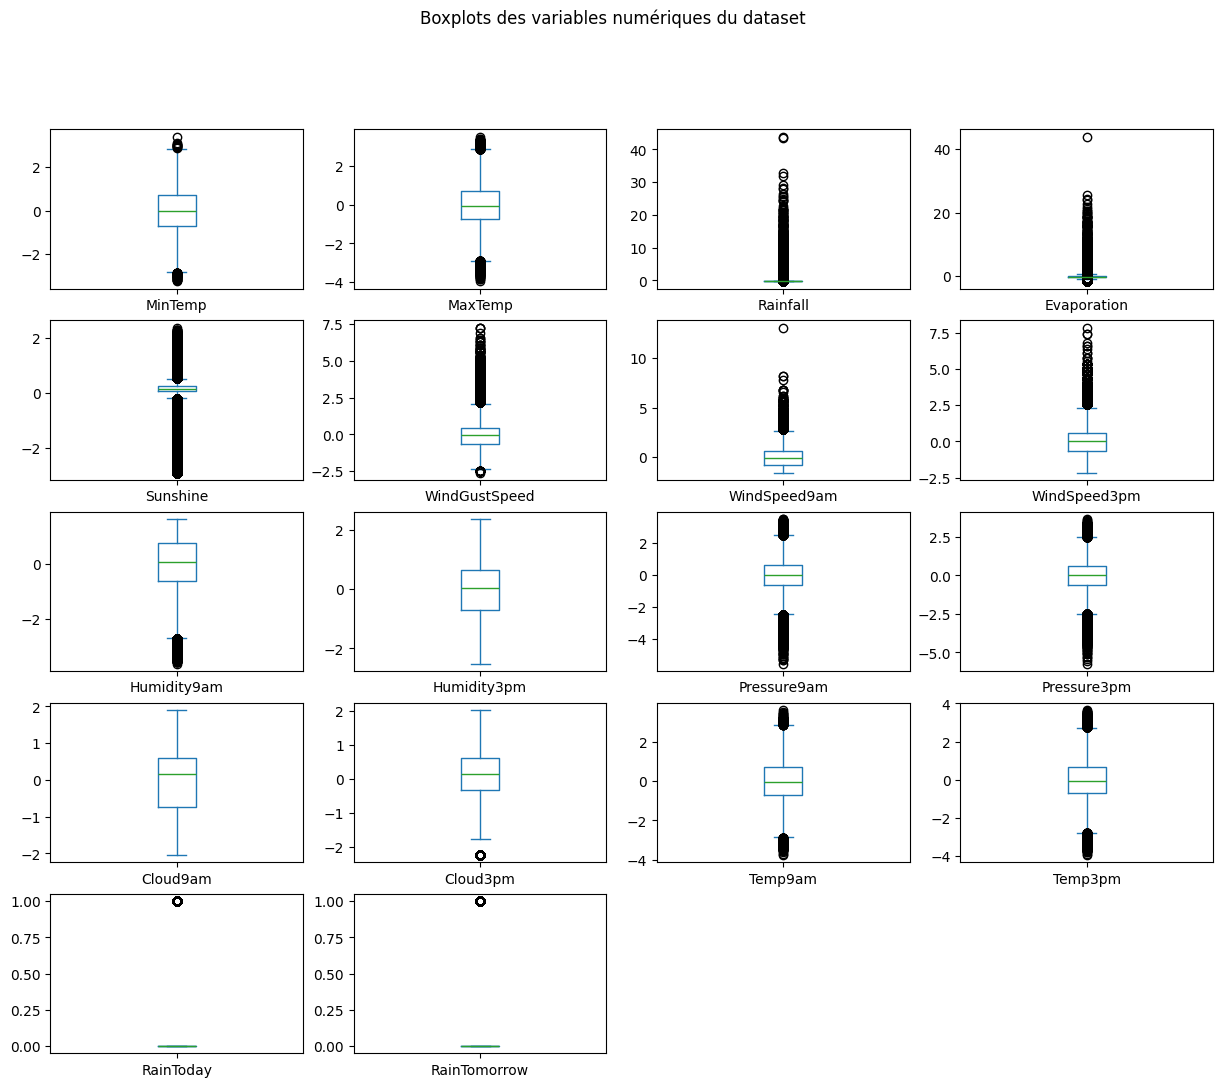

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Charger le dataset nettoyé
data = pd.read_csv("data_cleaned.csv")

# Sélectionner uniquement les colonnes numériques
num_cols = data.select_dtypes(include=['float64', 'int64']).columns

# Tracer les boxplots pour les variables numériques
data[num_cols].plot(kind='box', subplots=True, layout=(5,4), figsize=(15,12), sharex=False, sharey=False)
plt.suptitle("Boxplots des variables numériques du dataset")
plt.show()


Analyse du Boxplot des variables numériques

L'objectif principal de ces boxplots est d'identifier la distribution des données et de repérer les valeurs aberrantes (outliers).

Observations générales :

1. Présence d'outliers dans plusieurs variables
Rainfall, Evaporation, WindGustSpeed, WindSpeed9am, WindSpeed3pm, Pressure9am, Pressure3pm

→ Présentent beaucoup d'outliers (points au-dessus ou en dessous des moustaches).

MinTemp, MaxTemp, Sunshine, Cloud9am, Cloud3pm, Temp9am, Temp3pm*

→ Ont quelques outliers, mais ils semblent moins nombreux.

RainToday et RainTomorrow

→ Ce sont des variables binaires (0 ou 1), donc pas d'outliers ici.

2. Asymétrie et dispersion

Rainfall & Evaporation → Très étendues, avec des valeurs extrêmes bien au-dessus des autres points.

WindGustSpeed, WindSpeed9am, WindSpeed3pm → Très dispersées, avec des valeurs anormalement hautes.

Humidity9am et Humidity3pm → Relativement bien centrées, peu d'outliers visibles.

Possibles Causes des Outliers
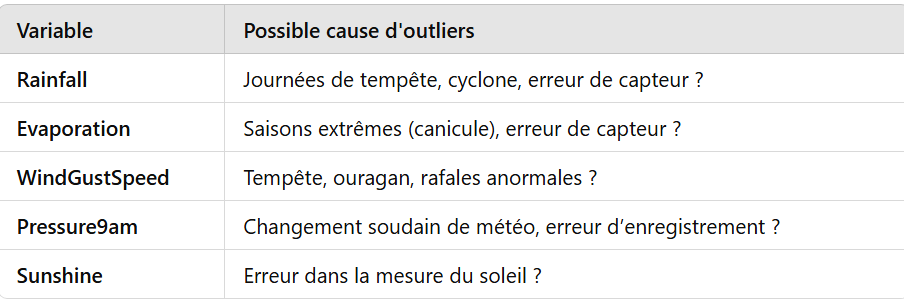

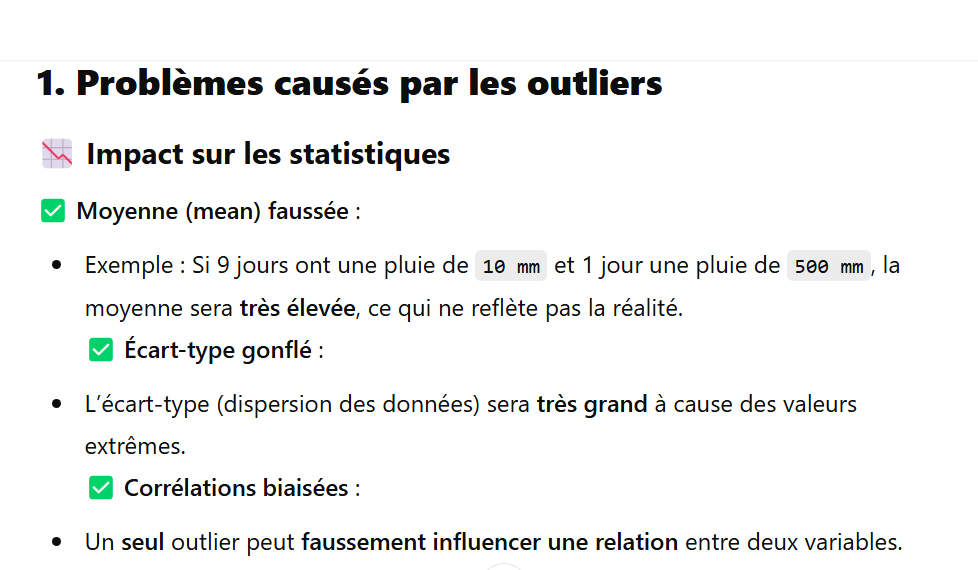

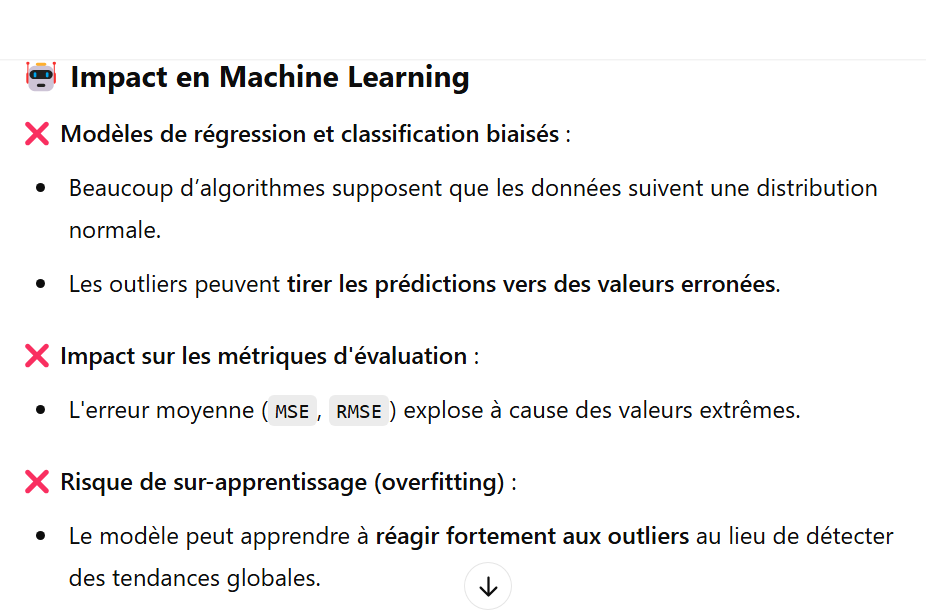

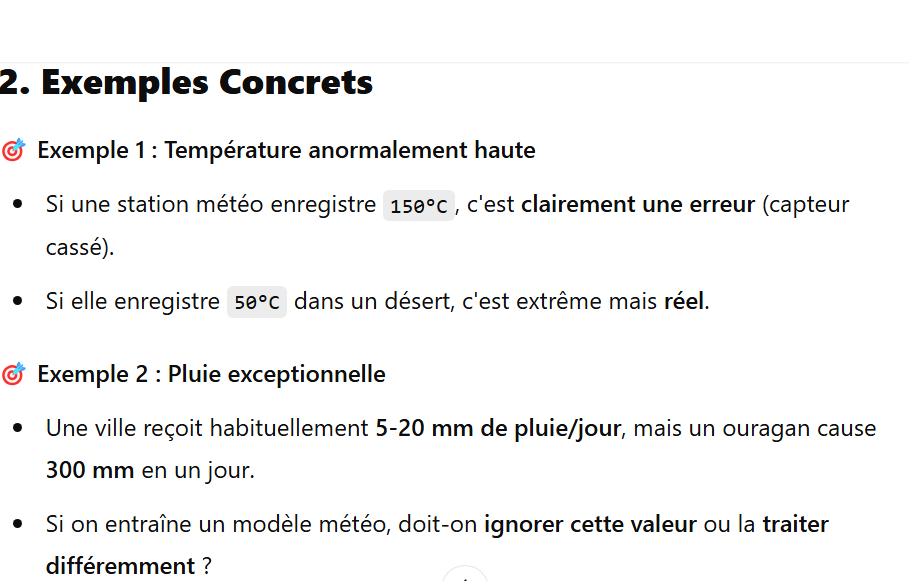

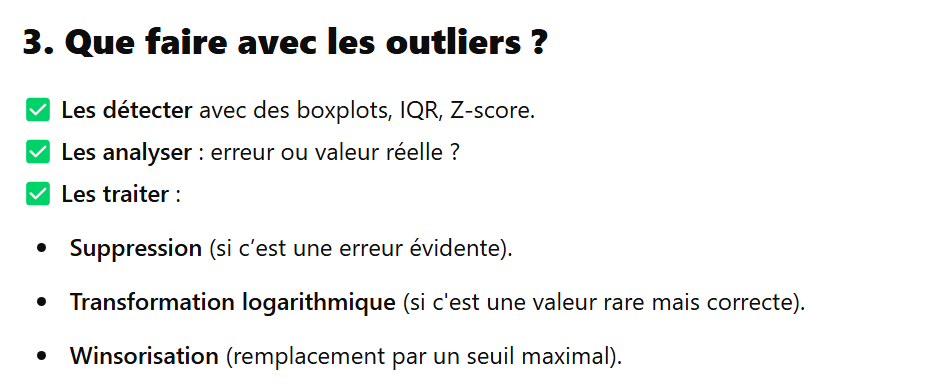

In [6]:
# Afficher les valeurs les plus élevées pour certaines colonnes critiques
cols_to_check = ["Rainfall", "Evaporation", "WindGustSpeed", "Pressure9am"]
for col in cols_to_check:
    print(f"Top valeurs de {col} :")
    print(data[col].sort_values(ascending=False).head(10))
    print("\n")


Top valeurs de Rainfall :
9368      43.945571
140071    43.540315
87242     32.908283
87995     31.740190
89371     29.189456
17321     28.331265
93344     27.949847
42010     26.543368
11681     25.899725
17579     25.506387
Name: Rainfall, dtype: float64


Top valeurs de Evaporation :
42358     43.985108
8831      25.487609
106968    24.292193
105935    23.914693
107290    22.687818
23954     21.901360
105965    21.083443
107968    20.517193
105949    20.391360
107599    20.013860
Name: Evaporation, dtype: float64


Top valeurs de WindGustSpeed :
94074     7.243246
106267    7.243246
20322     7.243246
131798    6.862175
139717    6.557317
43190     6.557317
130043    6.404888
107602    6.404888
66351     6.252460
108004    6.252460
Name: WindGustSpeed, dtype: float64


Top valeurs de Pressure9am :
112562    3.471111
109553    3.456248
49987     3.411662
46947     3.411662
133599    3.396799
127780    3.381937
130559    3.381937
133212    3.381937
48645     3.367075
133941    3.36707

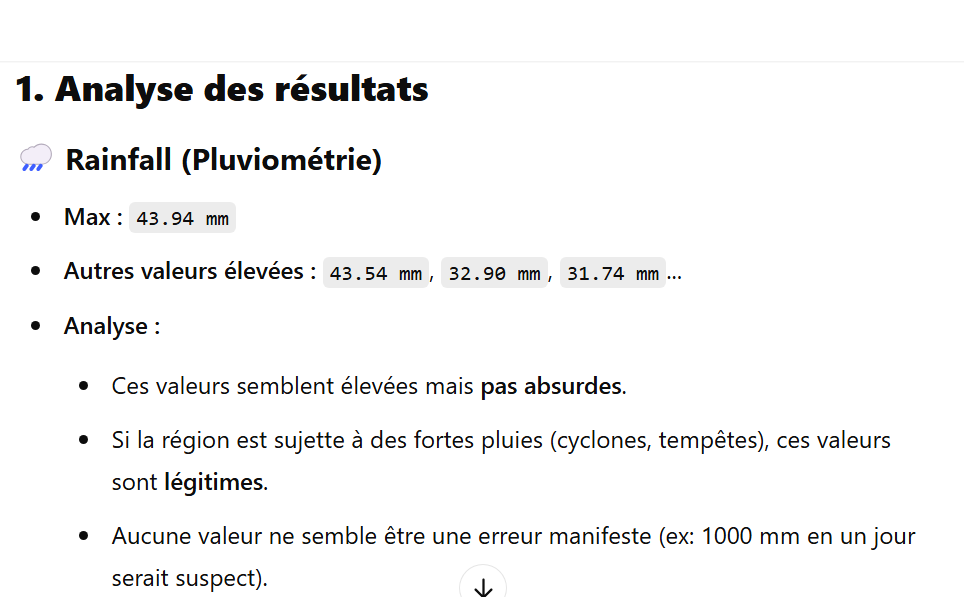

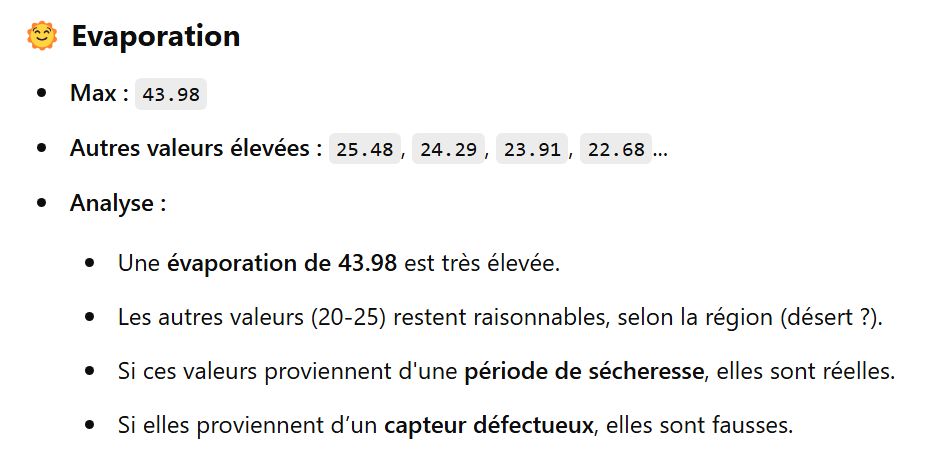

Matrice de dispersion (scatter matrix)

La matrice de dispersion permet de voir les relations entre les variables numériques.

Chaque nuage de points représente la corrélation entre deux variables.

La diagonale affiche les distributions des variables sous forme d'histogrammes.

Vérifier les valeurs manquantes


In [7]:
import pandas as pd

# Charger le dataset nettoyé
data = pd.read_csv("data_cleaned.csv")

# Vérifier les valeurs manquantes par colonne
missing_values = data.isnull().sum()

# Afficher uniquement les colonnes avec des valeurs manquantes
print("Valeurs manquantes par colonne :")
print(missing_values[missing_values > 0])


Valeurs manquantes par colonne :
Series([], dtype: int64)


Feature Engineering : Création/modification de nouvelles variables pour améliorer les performances du modèle.

Séparation des données en train et test : Pour entraîner et évaluer un modèle de manière équilibrée.

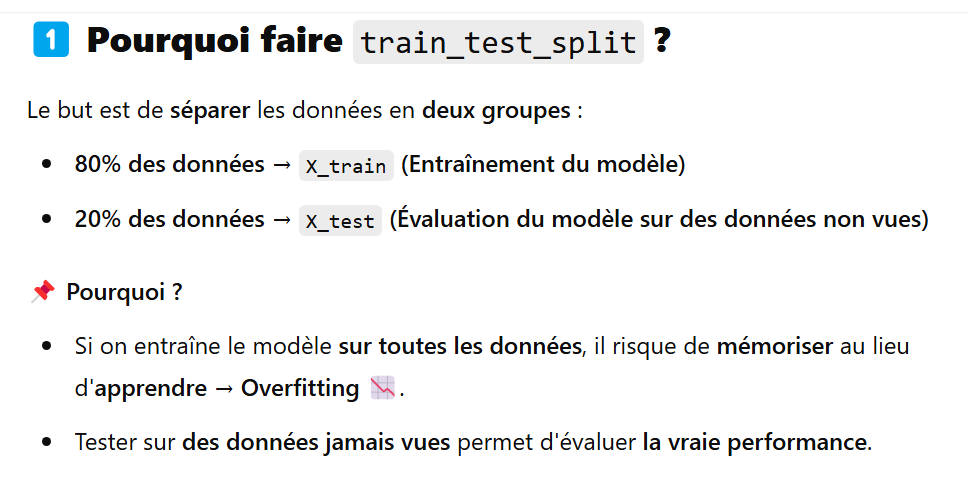

Dans notre cas, la colonne cible est RainTomorrow (0 = pas de pluie, 1 = pluie).

On doit donc séparer les features (X) et la cible (y), puis diviser les données :

In [8]:
from sklearn.model_selection import train_test_split

# Charger les données normalisées
data = pd.read_csv("data_cleaned.csv")

# Définir les features (X) et la target (y)
X = data.drop(columns=['RainTomorrow'])  # Supprime la colonne cible
y = data['RainTomorrow']  # Cible (prédiction)

# Séparer en 80% train et 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Données séparées en ensemble d'entraînement et de test.")


Données séparées en ensemble d'entraînement et de test.


Pourquoi random_state=42 ?

✅ Garantit la reproductibilité → Chaque exécution donnera la même séparation.

✅ Sans random_state, les données seront séparées différemment à chaque fois.

Feature Engineering : Doit-on créer de nouvelles features ?

💡 Idée : Ajouter des interactions entre les variables météo !
Par exemple :

Différence température jour/nuit → TempDiff = MaxTemp - MinTemp

Taux d'humidité → HumidityRatio = Humidity3pm / Humidity9am

Effet du vent → WindEffect = WindGustSpeed * WindSpeed3pm

👉 On peut l’ajouter avant train_test_split !

In [9]:
# Ajouter de nouvelles features
data["TempDiff"] = data["MaxTemp"] - data["MinTemp"]
data["HumidityRatio"] = data["Humidity3pm"] / (data["Humidity9am"] + 1)  # Éviter division par zéro
data["WindEffect"] = data["WindGustSpeed"] * data["WindSpeed3pm"]

# Mettre à jour les features (X) avant de diviser
X = data.drop(columns=['RainTomorrow'])
y = data['RainTomorrow']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Nouvelles features créées et données séparées.")


Nouvelles features créées et données séparées.


In [10]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(116368, 68) (29092, 68) (116368,) (29092,)


🔹 Étape 1 : Régression Linéaire
Nous allons :

Entraîner un modèle de régression linéaire sur les données d'entraînement.

Prédire les valeurs sur l'ensemble de test.

Évaluer la performance avec :

RMSE (Root Mean Squared Error) : Mesure l’erreur moyenne des prédictions.

R² Score : Indique le pourcentage de variance expliquée par le modèle.

Visualiser les prédictions vs les valeurs réelles.

📉 RMSE : 0.3432
📊 R² Score : 0.3150


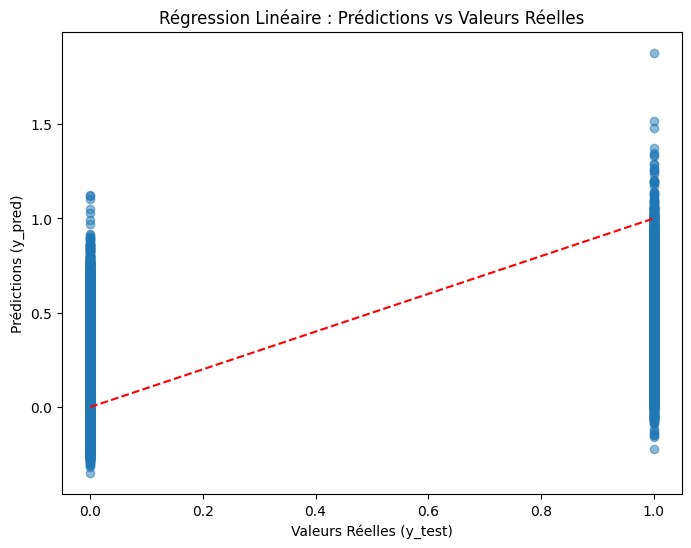

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Initialiser et entraîner le modèle
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

# Prédire sur l'ensemble de test
y_pred = lin_reg.predict(X_test)

# Calculer RMSE et R² Score
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"📉 RMSE : {rmse:.4f}")
print(f"📊 R² Score : {r2:.4f}")

# Visualisation : Prédictions vs Valeurs Réelles
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Valeurs Réelles (y_test)")
plt.ylabel("Prédictions (y_pred)")
plt.title("Régression Linéaire : Prédictions vs Valeurs Réelles")
plt.plot([0, 1], [0, 1], color='red', linestyle='dashed')  # Ligne idéale
plt.show()


📊 Analyse des résultats de la régression linéaire

1️⃣ Interprétation des métriques

📉 RMSE : 0.3432 → L’erreur moyenne des prédictions est d’environ 0.34 (plutôt élevée pour une classification).

📊 R² Score : 0.3150 → Seulement 31.5% de la variance des données est expliquée par le modèle (faible précision).

🛑 Conclusion :

La régression linéaire ne fonctionne pas très bien pour prédire RainTomorrow. Ce n'est pas surprenant, car RainTomorrow est une variable binaire (0 ou 1).



Que représentent les deux barres bleues ?
📊 Explication du graphique :

L'axe X (Valeurs Réelles - y_test)

0 : Pas de pluie
1 : Pluie
L'axe Y (Prédictions - y_pred)

On observe deux colonnes de points :
Colonne à gauche (0 réel) → Prédictions proches de 0 ✅

Colonne à droite (1 réel) → Prédictions proches de 1, mais dispersées ❌

🔴 Problème :

La régression linéaire ne prédit pas uniquement 0 ou 1. Elle produit des valeurs entre 0 et 1, parfois même supérieures à 1.5 ou négatives !

Cela signifie que le modèle n'est pas bien adapté à ce type de données.

📌 Pourquoi ?

La régression linéaire est une méthode pour les variables continues.
Or RainTomorrow est une variable catégorielle (0 ou 1).


##Régression Polynomiale (degré 2)

La régression polynomiale est une extension de la 
régression linéaire qui ajoute des termes 
quadratiques (x², x³, …) pour mieux capturer les 
relations non linéaires.



📉 RMSE (Polynomiale) : 0.3321
📊 R² Score (Polynomiale) : 0.3588


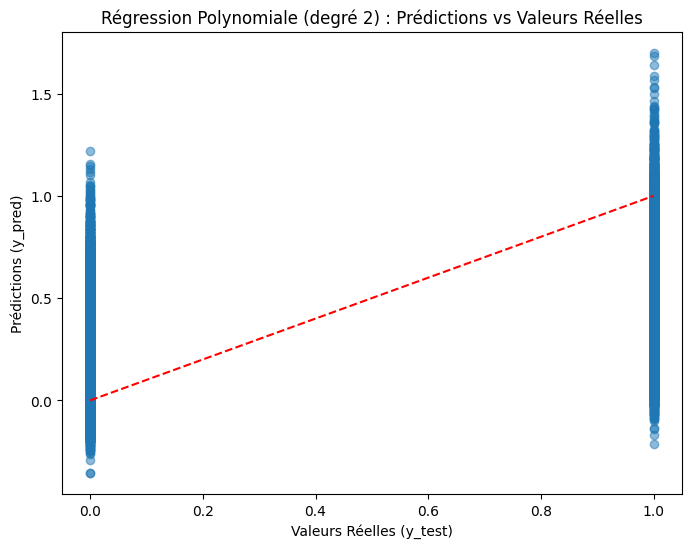

In [12]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Créer des features polynomiales (degré 2)
poly_features = PolynomialFeatures(degree=2, include_bias=False)

# Construire le pipeline : Transformation polynomiale + Régression linéaire
poly_reg = make_pipeline(poly_features, LinearRegression())

# Entraîner le modèle sur l'ensemble d'entraînement
poly_reg.fit(X_train, y_train)

# Prédire sur l'ensemble de test
y_pred_poly = poly_reg.predict(X_test)

# Calculer RMSE et R² Score
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
r2_poly = r2_score(y_test, y_pred_poly)

print(f"📉 RMSE (Polynomiale) : {rmse_poly:.4f}")
print(f"📊 R² Score (Polynomiale) : {r2_poly:.4f}")

# Visualisation : Prédictions vs Valeurs Réelles
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_poly, alpha=0.5)
plt.xlabel("Valeurs Réelles (y_test)")
plt.ylabel("Prédictions (y_pred)")
plt.title("Régression Polynomiale (degré 2) : Prédictions vs Valeurs Réelles")
plt.plot([0, 1], [0, 1], color='red', linestyle='dashed')  # Ligne idéale
plt.show()


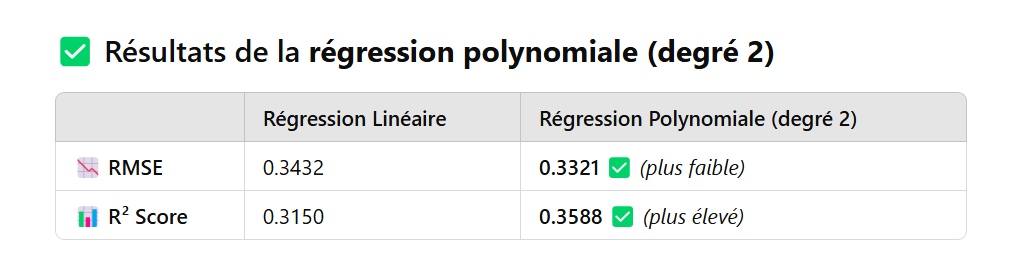

Interprétation
✔️ Amélioration légère mais réelle avec la régression polynomiale.

✔️ Le modèle arrive à capturer un peu mieux les relations non linéaires dans les données.

❌ Mais la performance reste limitée, car :

Les valeurs restent fortement concentrées autour de 0 et 1 (valeur cible binaire).

La régression n’est pas l’approche idéale pour une variable cible binaire.



##Régression Ridge & Lasso

Objectifs :

Entraîner des modèles Ridge et Lasso avec différentes valeurs de alpha.

Observer l’impact sur :

Les performances (RMSE & R²)

Les coefficients du modèle

Visualiser l'effet de la régularisation.

🔧 Comparaison Ridge et Lasso avec différents alpha

Alpha = 0.01
  Ridge -> RMSE: 0.3432, R²: 0.3150
  Lasso -> RMSE: 0.3480, R²: 0.2958

Alpha = 0.1
  Ridge -> RMSE: 0.3432, R²: 0.3150
  Lasso -> RMSE: 0.3871, R²: 0.1288

Alpha = 1
  Ridge -> RMSE: 0.3432, R²: 0.3150
  Lasso -> RMSE: 0.4147, R²: -0.0000

Alpha = 10
  Ridge -> RMSE: 0.3432, R²: 0.3150
  Lasso -> RMSE: 0.4147, R²: -0.0000

Alpha = 100
  Ridge -> RMSE: 0.3432, R²: 0.3150
  Lasso -> RMSE: 0.4147, R²: -0.0000



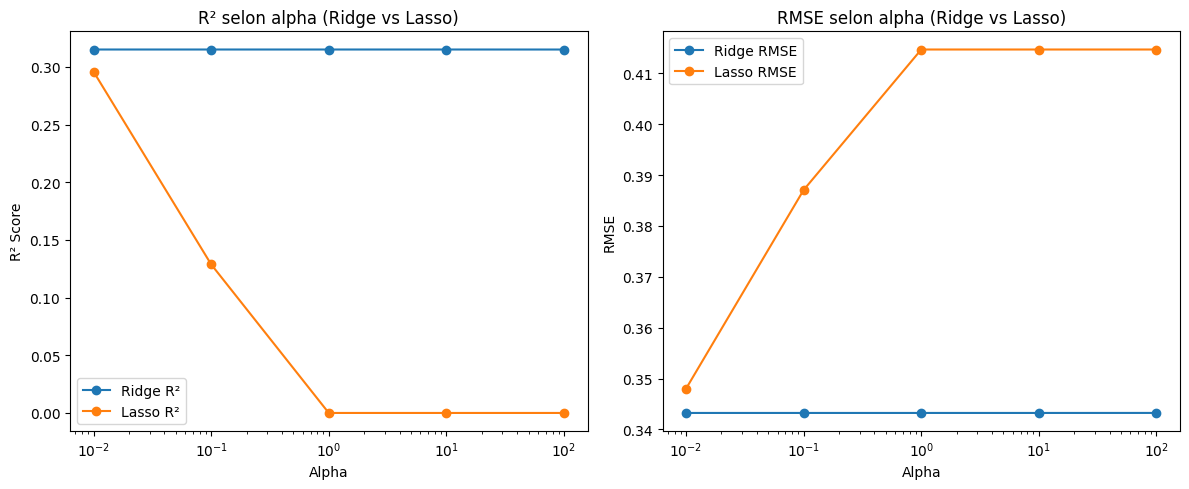

In [13]:
from sklearn.linear_model import Ridge, Lasso
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

alphas = [0.01, 0.1, 1, 10, 100]
ridge_rmse, ridge_r2, lasso_rmse, lasso_r2 = [], [], [], []

print("🔧 Comparaison Ridge et Lasso avec différents alpha\n")

for alpha in alphas:
    # Ridge
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train, y_train)
    y_pred_ridge = ridge.predict(X_test)
    rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
    r2_ridge = r2_score(y_test, y_pred_ridge)
    ridge_rmse.append(rmse_ridge)
    ridge_r2.append(r2_ridge)

    # Lasso
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train, y_train)
    y_pred_lasso = lasso.predict(X_test)
    rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
    r2_lasso = r2_score(y_test, y_pred_lasso)
    lasso_rmse.append(rmse_lasso)
    lasso_r2.append(r2_lasso)

    print(f"Alpha = {alpha}")
    print(f"  Ridge -> RMSE: {rmse_ridge:.4f}, R²: {r2_ridge:.4f}")
    print(f"  Lasso -> RMSE: {rmse_lasso:.4f}, R²: {r2_lasso:.4f}\n")

# Visualiser les coefficients
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(alphas, ridge_r2, marker='o', label='Ridge R²')
plt.plot(alphas, lasso_r2, marker='o', label='Lasso R²')
plt.xlabel("Alpha")
plt.ylabel("R² Score")
plt.title("R² selon alpha (Ridge vs Lasso)")
plt.xscale("log")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(alphas, ridge_rmse, marker='o', label='Ridge RMSE')
plt.plot(alphas, lasso_rmse, marker='o', label='Lasso RMSE')
plt.xlabel("Alpha")
plt.ylabel("RMSE")
plt.title("RMSE selon alpha (Ridge vs Lasso)")
plt.xscale("log")
plt.legend()

plt.tight_layout()
plt.show()


📌 Ce qu'on observe :
🔷 Ridge Regression (L2 régularisation)
Stable et performant quelle que soit la valeur de alpha.

Les résultats restent identiques à la régression linéaire.

📈 R² constant à 0.3150, ce qui confirme que Ridge ne dégrade pas le modèle.

🔶 Lasso Regression (L1 régularisation)
Dès que alpha > 0.01, les performances se dégradent fortement.

Pour alpha = 1 ou plus :

R² chute à 0.0000 ❌

Cela signifie que Lasso annule tous les coefficients (surpénalisation).

📊 Pourquoi ce comportement ?
Lasso est très sensible à alpha :

Avec des features peu corrélées à la cible, il peut mettre tous les poids à zéro.

Ici, comme RainTomorrow est binaire et que la relation avec les variables est faible, Lasso "abandonne" trop vite quand alpha augmente.

Ridge, à l’inverse, réduit les coefficients sans les annuler, ce qui est plus stable ici.

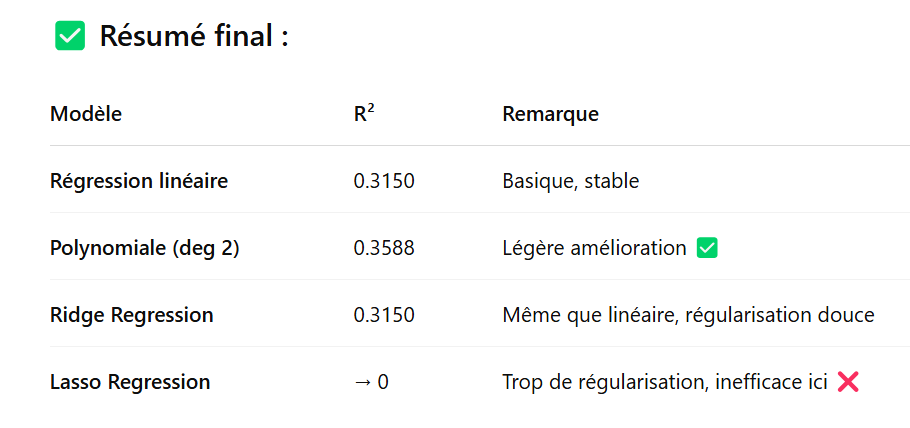

##modèle Random Forest


Utiliser un modèle Random Forest Classifier pour prédire RainTomorrow et le comparer aux modèles précédents (logistique, linéaire...).



✅ Accuracy (Random Forest) : 0.8508
📈 AUC ROC (Random Forest) : 0.8768

📊 Classification Report :

              precision    recall  f1-score   support

           0       0.87      0.96      0.91     22672
           1       0.76      0.48      0.59      6420

    accuracy                           0.85     29092
   macro avg       0.81      0.72      0.75     29092
weighted avg       0.84      0.85      0.84     29092

🧮 Matrice de confusion :
 [[21684   988]
 [ 3353  3067]]


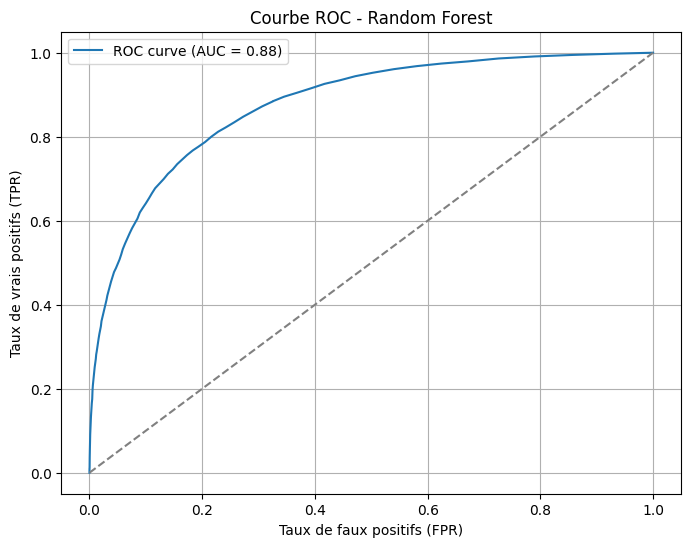

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Initialiser et entraîner le modèle Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Prédictions
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

# Évaluation du modèle
accuracy = accuracy_score(y_test, y_pred_rf)
roc_auc = roc_auc_score(y_test, y_prob_rf)
print(f"✅ Accuracy (Random Forest) : {accuracy:.4f}")
print(f"📈 AUC ROC (Random Forest) : {roc_auc:.4f}")
print("\n📊 Classification Report :\n")
print(classification_report(y_test, y_pred_rf))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred_rf)
print("🧮 Matrice de confusion :\n", cm)

# Courbe ROC
fpr, tpr, _ = roc_curve(y_test, y_prob_rf)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("Taux de faux positifs (FPR)")
plt.ylabel("Taux de vrais positifs (TPR)")
plt.title("Courbe ROC - Random Forest")
plt.legend()
plt.grid(True)
plt.show()


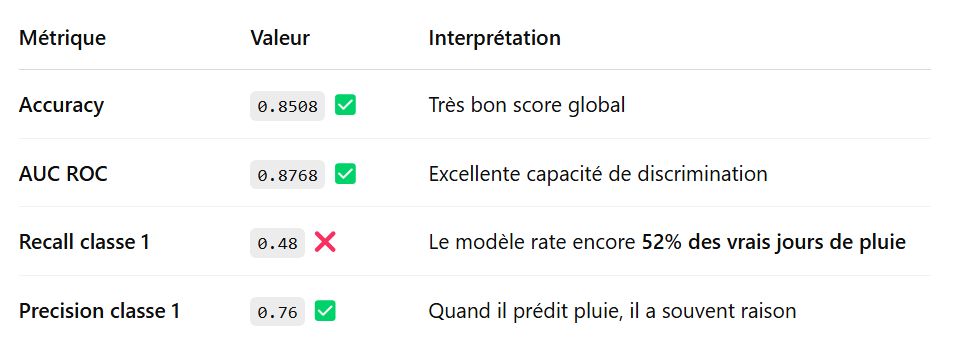

 Feature Importance (Interprétation)

Objectif :

Identifier quelles variables influencent le plus la prédiction de RainTomorrow.

Expliquer ce que le modèle Random Forest apprend.



🔝 Top 10 variables les plus influentes :

          Feature  Importance
9     Humidity3pm    0.120983
66  HumidityRatio    0.065870
65       TempDiff    0.059883
11    Pressure3pm    0.053660
8     Humidity9am    0.048064
2        Rainfall    0.048046
10    Pressure9am    0.045671
5   WindGustSpeed    0.043035
4        Sunshine    0.042800
15        Temp3pm    0.039785


C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_17036\1544671648.py:28: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Utilisateur\OneDrive - UPEC\Bureau\TensorFlow\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


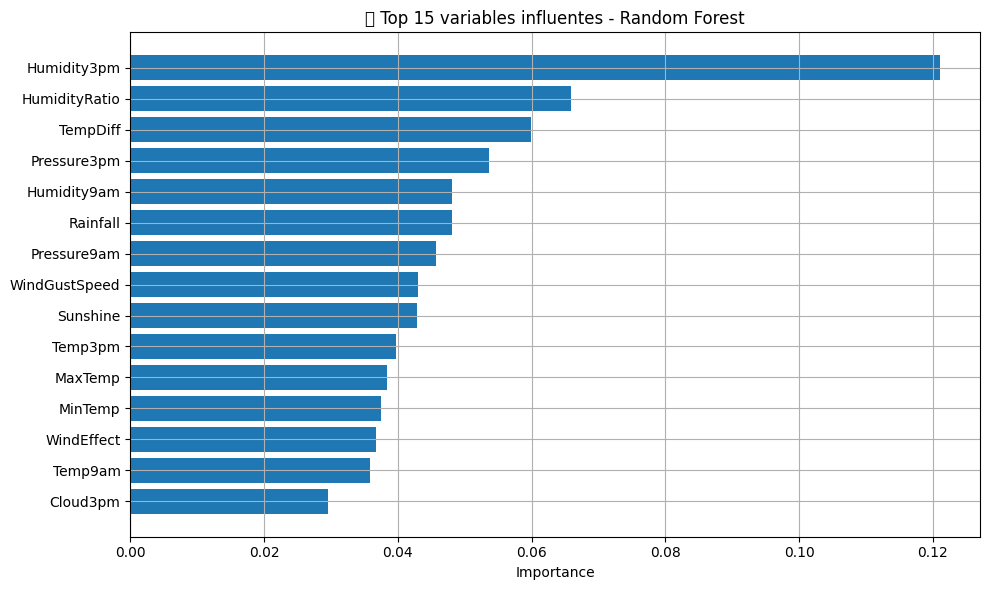

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Récupérer les noms des colonnes (features)
feature_names = X_train.columns

# Récupérer l'importance des features depuis le modèle Random Forest
importances = rf.feature_importances_

# Créer un DataFrame pour trier et visualiser
feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Afficher les 10 features les plus importantes
print("🔝 Top 10 variables les plus influentes :\n")
print(feat_imp.head(10))

# Visualiser
plt.figure(figsize=(10, 6))
plt.barh(feat_imp['Feature'].head(15), feat_imp['Importance'].head(15))
plt.gca().invert_yaxis()
plt.title("🎯 Top 15 variables influentes - Random Forest")
plt.xlabel("Importance")
plt.grid(True)
plt.tight_layout()
plt.show()


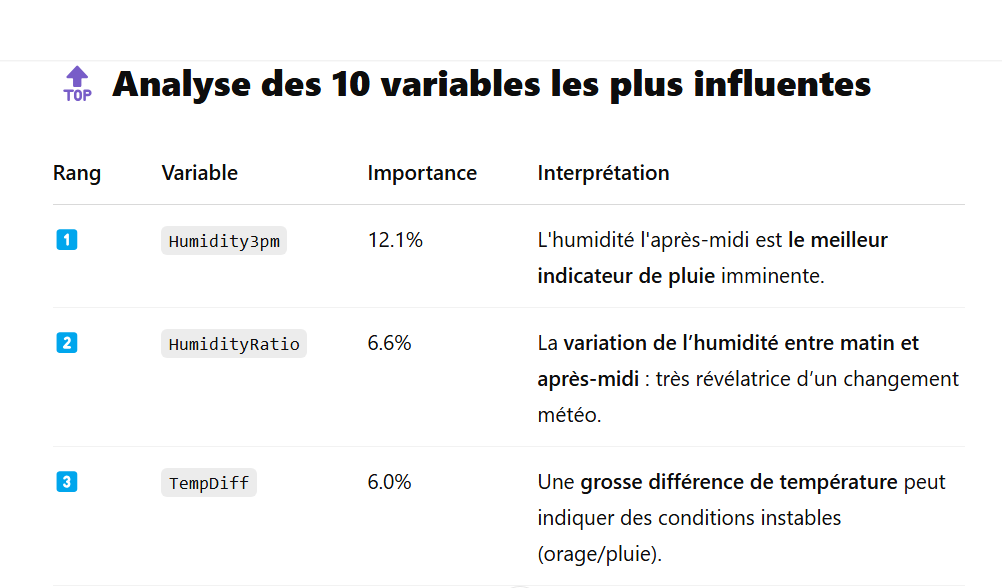
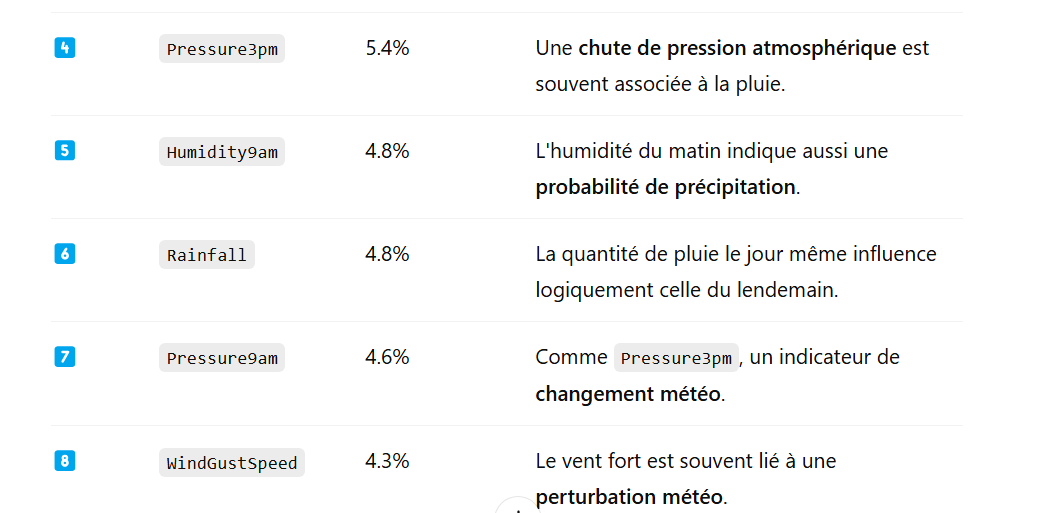
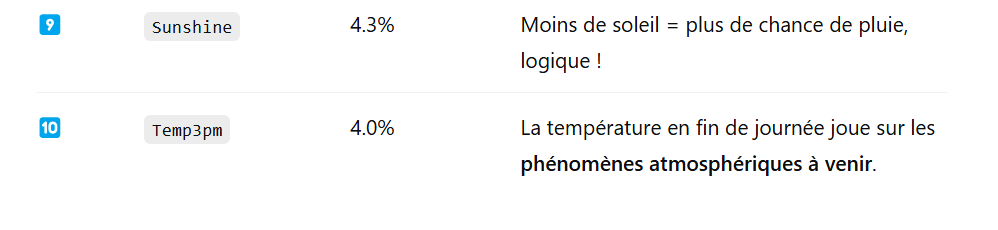

Ce que ça montre :

Le modèle apprend des relations météo cohérentes, ce qui est très 
bon signe.

Les features créées (HumidityRatio, TempDiff) sont dans le top 3, bravo ! 



##SVM Classifier

Objectif :

Tester un SVM (Support Vector Machine) sur notre dataset pour prédire RainTomorrow.

✅ Accuracy (SVM) : 0.8268
📈 AUC ROC (SVM) : 0.8541

📊 Classification Report :

              precision    recall  f1-score   support

           0       0.83      0.98      0.90     22672
           1       0.80      0.29      0.42      6420

    accuracy                           0.83     29092
   macro avg       0.82      0.63      0.66     29092
weighted avg       0.82      0.83      0.79     29092

🧮 Matrice de confusion :
 [[22222   450]
 [ 4588  1832]]


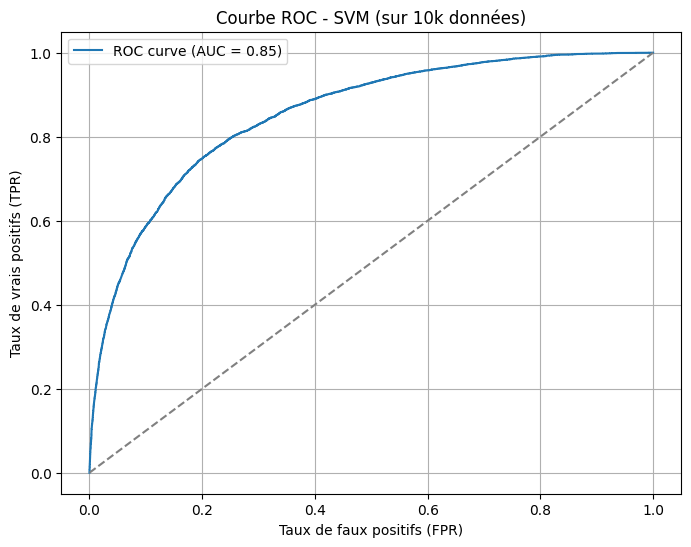

In [10]:
from sklearn.svm import SVC
from sklearn.utils import resample
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Sous-échantillonnage à 10 000 lignes
X_train_sampled, y_train_sampled = resample(X_train, y_train, n_samples=10000, random_state=42)

# Entraîner le SVM sur le sous-échantillon
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train_sampled, y_train_sampled)

# Prédictions sur tout X_test
y_pred_svm = svm_model.predict(X_test)
y_prob_svm = svm_model.predict_proba(X_test)[:, 1]

# Évaluation
accuracy = accuracy_score(y_test, y_pred_svm)
roc_auc = roc_auc_score(y_test, y_prob_svm)
print(f"✅ Accuracy (SVM) : {accuracy:.4f}")
print(f"📈 AUC ROC (SVM) : {roc_auc:.4f}")
print("\n📊 Classification Report :\n")
print(classification_report(y_test, y_pred_svm))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred_svm)
print("🧮 Matrice de confusion :\n", cm)

# Courbe ROC
fpr, tpr, _ = roc_curve(y_test, y_prob_svm)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("Taux de faux positifs (FPR)")
plt.ylabel("Taux de vrais positifs (TPR)")
plt.title("Courbe ROC - SVM (sur 10k données)")
plt.legend()
plt.grid(True)
plt.show()


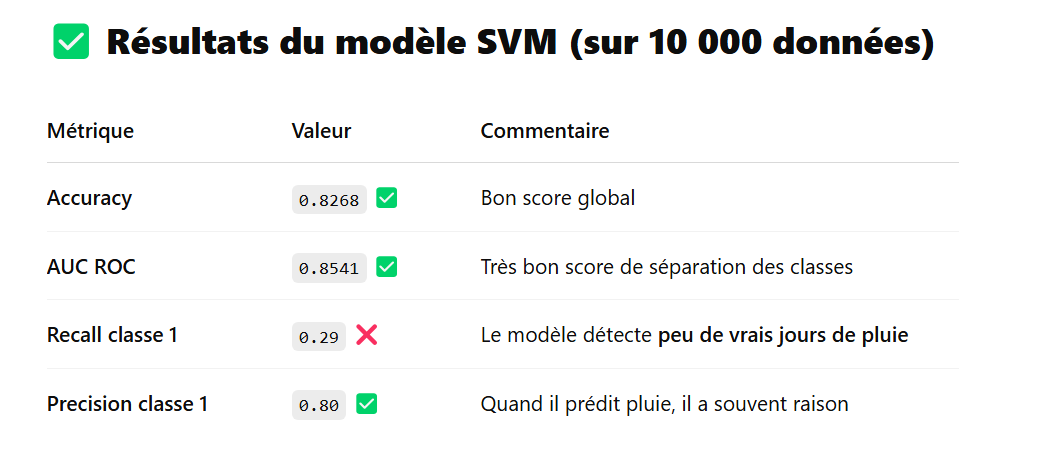

Interprétation :

Le SVM préfère ne pas prendre de risque : il prédit souvent "pas de pluie".

Il est donc précis, mais peu sensible (low recall pour la pluie).

Il classifie très bien les journées sans pluie, mais manque plus de la moitié des journées de pluie.

##KNN Classifier

Objectif :

Tester un modèle KNN pour prédire RainTomorrow
et le comparer aux autres modèles.



✅ Accuracy (KNN) : 0.8312
📈 AUC ROC (KNN) : 0.8097

📊 Classification Report :

              precision    recall  f1-score   support

           0       0.86      0.94      0.90     22672
           1       0.67      0.46      0.55      6420

    accuracy                           0.83     29092
   macro avg       0.77      0.70      0.72     29092
weighted avg       0.82      0.83      0.82     29092

🧮 Matrice de confusion :
 [[21203  1469]
 [ 3441  2979]]


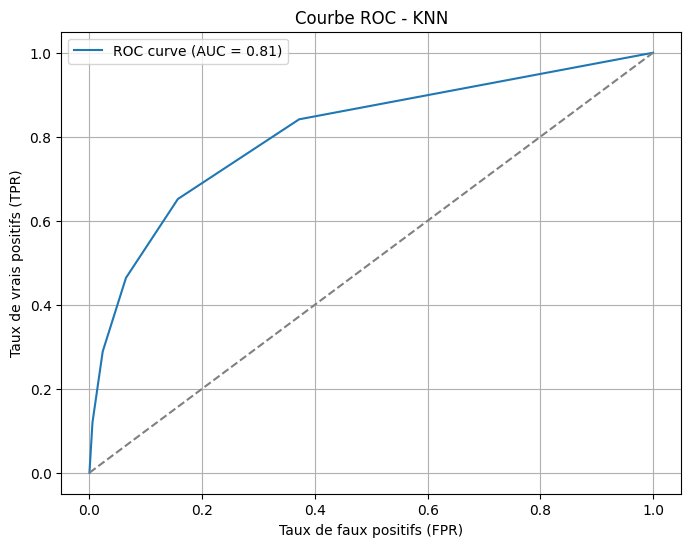

In [11]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Initialiser le modèle KNN
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

# Prédictions
y_pred_knn = knn_model.predict(X_test)
y_prob_knn = knn_model.predict_proba(X_test)[:, 1]

# Évaluation
accuracy = accuracy_score(y_test, y_pred_knn)
roc_auc = roc_auc_score(y_test, y_prob_knn)
print(f"✅ Accuracy (KNN) : {accuracy:.4f}")
print(f"📈 AUC ROC (KNN) : {roc_auc:.4f}")
print("\n📊 Classification Report :\n")
print(classification_report(y_test, y_pred_knn))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred_knn)
print("🧮 Matrice de confusion :\n", cm)

# Courbe ROC
fpr, tpr, _ = roc_curve(y_test, y_prob_knn)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("Taux de faux positifs (FPR)")
plt.ylabel("Taux de vrais positifs (TPR)")
plt.title("Courbe ROC - KNN")
plt.legend()
plt.grid(True)
plt.show()


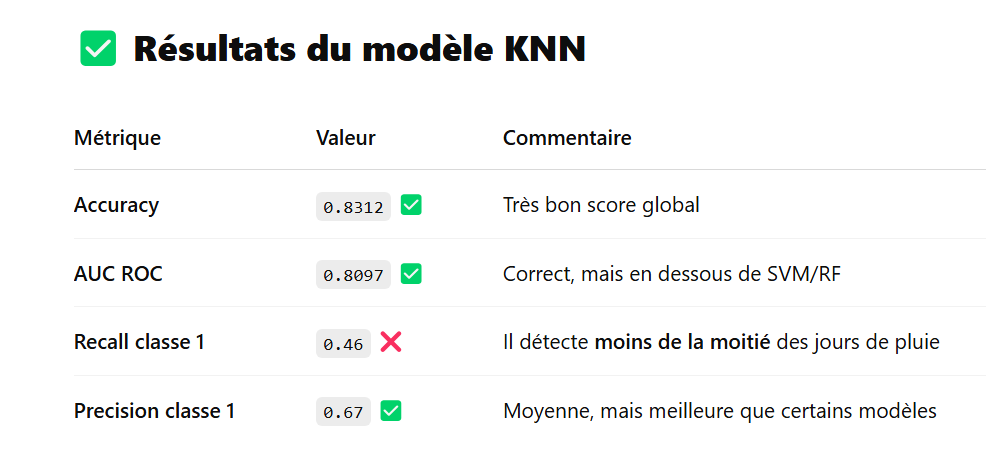

Interprétation :

Il est un peu meilleur que SVM pour détecter la pluie (recall à 0.46 contre 0.29)

Mais reste moins performant que Random Forest sur tous les plans.

Il est aussi plus coûteux en calcul que Logistique ou RF.

